In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import optax
import matplotlib.pyplot as plt
import jax
from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [3]:
from typing import Optional
from jaxtyping import ArrayLike, Bool, Float
import warnings

In [4]:
def func(x):
    """Latent function."""
    return 1.0 * jnp.sin(x * 3 * jnp.pi) + \
           0.3 * jnp.cos(x * 9 * jnp.pi) + \
           0.5 * jnp.sin(x * 7 * jnp.pi)


# Number of training examples
n = 100

# Number of inducing variables
m = 30

# Noise
sigma_y = 0.2

# Noisy training data
X = jnp.linspace(-1.0, 1.0, n).reshape(-1, 1)
y = func(X) + sigma_y * random.normal(random.PRNGKey(0), shape=(n, 1))

# Test data
X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
f_true = func(X_test)

# Inducing inputs
X_m = jnp.linspace(-0.4, 0.4, m).reshape(-1, 1)

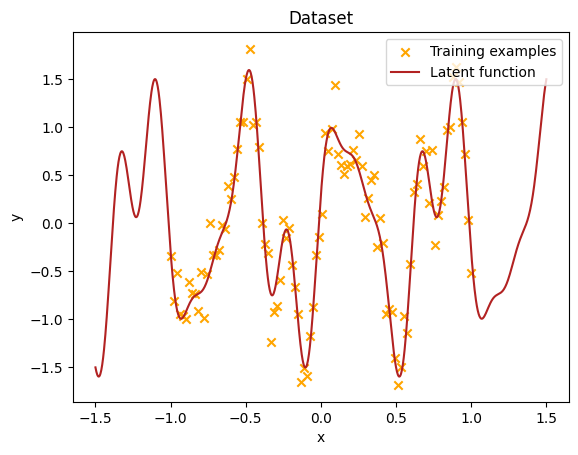

In [5]:
plt.scatter(X, y, label='Training examples', marker='x', color='orange')
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)
plt.title('Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

In [6]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared
num_inducing_points = 30
initial_inducing_points = jnp.linspace(X.min(), X.max(), num=num_inducing_points, endpoint=True)#[:,jnp.newaxis]
kernel_fn = ExpSquared

In [7]:
params = {'kernel': {'coefficient': jnp.array(0.9, dtype=jnp.float64), 'log_scale': jnp.array(0.0, dtype=jnp.float64)}, 'mean': {}, 'likelihood':{'log_diag': jnp.array(-2.5, dtype=jnp.float64),}, 'inducing_point_locations':jnp.array(initial_inducing_points, dtype=jnp.float64)}

In [8]:
from jax_mc_pilco.model_learning.gp.gaussian_process import SparseVariationalGaussianProcess, svgp_fit

In [9]:
gp = SparseVariationalGaussianProcess(kernel_fn,X,y,num_inducing_points,params)

In [10]:
%time
gp = svgp_fit(gp)

CPU times: user 1e+03 ns, sys: 1e+03 ns, total: 2 µs
Wall time: 5.25 µs


In [11]:
gp.params

{'inducing_point_locations': Array([-0.93392335, -0.99051528, -0.86905321, -0.80335621, -0.73956044,
        -0.67527927, -0.60969053, -0.47909571, -0.54339821, -0.40416514,
        -0.33346351, -0.27584189, -0.20889481, -0.13496918, -0.06126166,
         0.08368256,  0.01103166,  0.15387143,  0.22238071,  0.28944895,
         0.35718349,  0.42647738,  0.56339815,  0.49705904,  0.63557935,
         0.71172393,  0.78575925,  0.85760641,  0.92832196,  0.98960231],      dtype=float64),
 'kernel': {'coefficient': Array(0.80508531, dtype=float64),
  'log_scale': Array(-2.46052364, dtype=float64)},
 'likelihood': {'log_diag': Array(-1.40728161, dtype=float64)},
 'mean': {}}

In [12]:
%%time
f_test, f_test_cov = gp.predict(X_test)

CPU times: user 381 ms, sys: 49.2 ms, total: 430 ms
Wall time: 383 ms


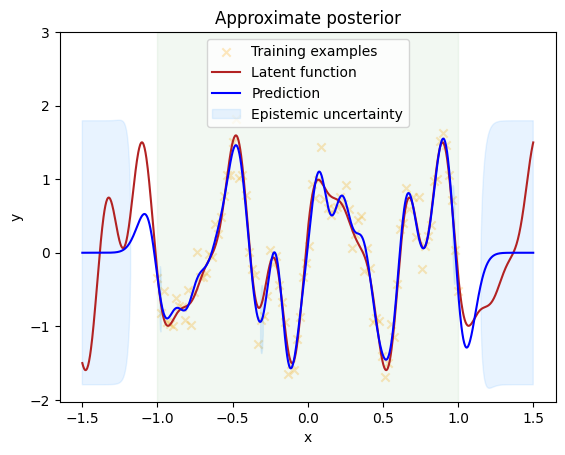

In [14]:
f_test_var = jnp.diag(f_test_cov)
f_test_std = jnp.sqrt(f_test_var)

plt.scatter(X, y, label='Training examples', marker='x', color='orange', alpha=0.25)
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)

plt.plot(X_test, f_test, label='Prediction', c='blue')
plt.fill_between(X_test.ravel(), 
                 f_test.ravel() + 2 * f_test_std, 
                 f_test.ravel() - 2 * f_test_std,
                 label='Epistemic uncertainty',
                 color='dodgerblue', alpha=0.1)
plt.title('Approximate posterior')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(None, 3.0)
plt.legend();
plt.axvspan(X.min(),X.max(),color='green',alpha=0.05);

In [15]:
%%time
X_test_new = np.linspace(-1.5, 1.5, 2500).reshape(1, -1)
f_t, f_t_cov = gp.predict(X_test_new)

CPU times: user 291 ms, sys: 24.1 ms, total: 316 ms
Wall time: 291 ms
